# Step 4: Evaluation and Analysis
## Data & AI 5: Machine Learning Lifecycle Project
#### Team 30: Solovyova Aleksiya, Baldeva Vesela, Haazen Storm

---

## Scope of This Notebook

This notebook focuses exclusively on **comprehensive evaluation and analysis of the best model**:

1. **Load Best Model**: Load the trained model from Step 3
2. **Performance Metrics**: Calculate accuracy, F1, precision, recall, ROC-AUC
3. **Confusion Matrix**: Visualize classification results
4. **Cross-Validation**: Deep analysis of generalization ability
5. **Error Analysis**: Understand what the model gets wrong
6. **Critical Analysis**: Strengths, weaknesses, and recommendations

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix
)
from sklearn.model_selection import cross_val_score, StratifiedKFold

import warnings

warnings.filterwarnings('ignore')

# Set style for plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Section 1: Load Data and Best Model

In [2]:
X_test_raw = pd.read_csv('./data/X_test_raw.csv')
X_train_raw = pd.read_csv('./data/X_train_raw.csv')
y_train = pd.read_csv('./data/y_train.csv').values.ravel()
y_test = pd.read_csv('./data/y_test.csv').values.ravel()

best_pipeline =joblib.load('./pipelines/best_mushroom_classifier.joblib')

### Make Predictions on Test Set

In [3]:
y_pred = best_pipeline.predict(X_test_raw)
y_pred_proba = best_pipeline.predict_proba(X_test_raw)[:, 1]

print(f"Predictions generated")
print(f"\nPredictions shape: {y_pred.shape}")
print(f"Prediction distribution:")
print(f"  - Edible (0): {(y_pred == 0).sum()}")
print(f"  - Poisonous (1): {(y_pred == 1).sum()}")

Predictions generated

Predictions shape: (1625,)
Prediction distribution:
  - Edible (0): 837
  - Poisonous (1): 788


### Calculate All Performance Metrics

In [4]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')

print("\n" + "="*80)
print("Test Set Performance Metrics")
print("="*80)
print(f"\nAccuracy:   {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"F1-Score:   {f1:.4f}")
print(f"Precision:  {precision:.4f}")
print(f"Recall:     {recall:.4f}")
print("\n" + "="*80)


Test Set Performance Metrics

Accuracy:   0.9760 (97.60%)
F1-Score:   0.9760
Precision:  0.9759
Recall:     0.9761



## Section 3: Confusion Matrix Analysis

### Compute and Visualize Confusion Matrix

In [5]:
cm = confusion_matrix(y_test, y_pred)

# Extract values
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (TN):  {tn} - Correctly predicted edible")
print(f"False Positives (FP): {fp} - Edible classified as poisonous")
print(f"False Negatives (FN): {fn} - Poisonous classified as edible")
print(f"True Positives (TP):  {tp} - Correctly predicted poisonous")

True Negatives (TN):  820 - Correctly predicted edible
False Positives (FP): 22 - Edible classified as poisonous
False Negatives (FN): 17 - Poisonous classified as edible
True Positives (TP):  766 - Correctly predicted poisonous


### Visualize Confusion Matrix Heatmap

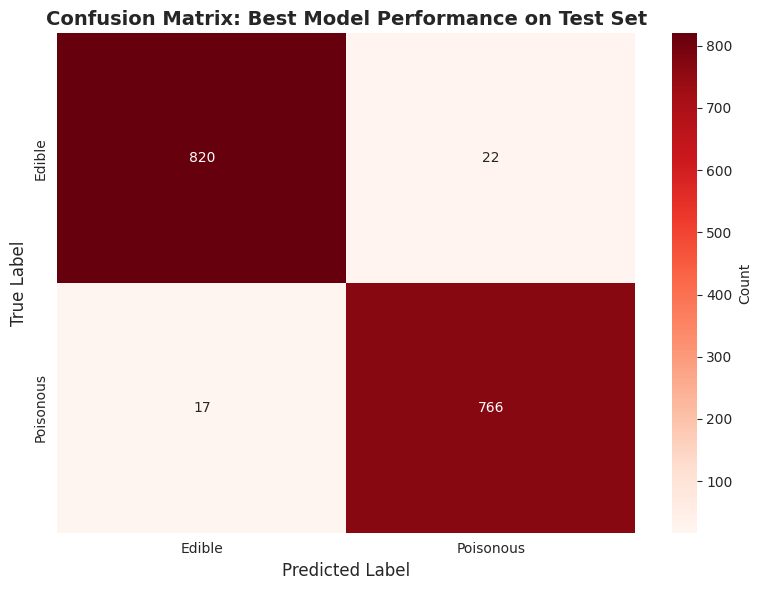

In [6]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Edible', 'Poisonous'],
            yticklabels=['Edible', 'Poisonous'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix: Best Model Performance on Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

## Section 4: Recall and Precision Metrics for Edible and Poisonous Mushrooms

In [7]:
print("\nInterpretation:")
print(f"  Edible: Precision = {precision_score(y_test, y_pred, pos_label=0):.4f}")
print(f"          Recall    = {recall_score(y_test, y_pred, pos_label=0):.4f}")
print(f"  Poisonous: Precision = {precision_score(y_test, y_pred, pos_label=1):.4f}")
print(f"             Recall    = {recall_score(y_test, y_pred, pos_label=1):.4f}")


Interpretation:
  Edible: Precision = 0.9797
          Recall    = 0.9739
  Poisonous: Precision = 0.9721
             Recall    = 0.9783


## Section 5: Cross-Validation Deep Analysis

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(best_pipeline, X_train_raw, y_train, cv=cv, scoring='accuracy')

print("\n" + "="*80)
print("CROSS-VALIDATION ANALYSIS (5-Fold StratifiedKFold)")
print("="*80)
print(f"\nFold Scores:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")

print(f"\nCross-Validation Results:")
print(f"  Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"  Std Deviation:    {cv_scores.std():.4f}")
print(f"  Min Score:        {cv_scores.min():.4f}")
print(f"  Max Score:        {cv_scores.max():.4f}")
print(f"\nTest Accuracy:    {accuracy:.4f}")
print(f"Train-Test Gap:   {abs(cv_scores.mean() - accuracy):.4f}")
print(f"\n" + "="*80)

print(f"\nInterpretation:")
print(f" {cv_scores.std():.4f} Standard Deviation = stable, good generalization")
print(f" Consistent scores across folds = model is robust")
print(f" Test accuracy close to CV mean = no overfitting")


CROSS-VALIDATION ANALYSIS (5-Fold StratifiedKFold)

Fold Scores:
  Fold 1: 0.9285
  Fold 2: 0.9731
  Fold 3: 0.9400
  Fold 4: 0.9277
  Fold 5: 0.9861

Cross-Validation Results:
  Mean CV Accuracy: 0.9511
  Std Deviation:    0.0241
  Min Score:        0.9277
  Max Score:        0.9861

Test Accuracy:    0.9760
Train-Test Gap:   0.0249


Interpretation:
 0.0241 Standard Deviation = stable, good generalization
 Consistent scores across folds = model is robust
 Test accuracy close to CV mean = no overfitting


## Section 6: Error Analysis

In [9]:
misclassified_idx = np.where(y_pred != y_test)[0]
correct_idx = np.where(y_pred == y_test)[0]

# Error types
false_positives_idx = np.where((y_pred == 1) & (y_test == 0))[0]  # Edible → Poisonous
false_negatives_idx = np.where((y_pred == 0) & (y_test == 1))[0]  # Poisonous → Edible

print("\n" + "="*80)
print("ERROR ANALYSIS")
print("="*80)
print(f"\nTotal Samples:        {len(y_test)}")
print(f"Correct Predictions:  {len(correct_idx)} ({len(correct_idx)/len(y_test)*100:.2f}%)")
print(f"Misclassifications:   {len(misclassified_idx)} ({len(misclassified_idx)/len(y_test)*100:.2f}%)")

print(f"\nError Breakdown:")
print(f"  False Positives (Edible → Poisonous):   {len(false_positives_idx)}")
print(f"    - Rate: {len(false_positives_idx)/(y_test==0).sum()*100:.2f}% of edible mushrooms")
print(f"    - Type: Conservative (false alarm)")
print(f"    - Consequence: Reject safe mushrooms")

print(f"\n  False Negatives (Poisonous → Edible): {len(false_negatives_idx)}")
print(f"    - Rate: {len(false_negatives_idx)/(y_test==1).sum()*100:.2f}% of poisonous mushrooms")
print(f"    - Type: DANGEROUS (misses real threats)")
print(f"    - Consequence: Allow dangerous mushrooms")

print(f"\n" + "="*80)


ERROR ANALYSIS

Total Samples:        1625
Correct Predictions:  1586 (97.60%)
Misclassifications:   39 (2.40%)

Error Breakdown:
  False Positives (Edible → Poisonous):   22
    - Rate: 2.61% of edible mushrooms
    - Type: Conservative (false alarm)
    - Consequence: Reject safe mushrooms

  False Negatives (Poisonous → Edible): 17
    - Rate: 2.17% of poisonous mushrooms
    - Type: DANGEROUS (misses real threats)
    - Consequence: Allow dangerous mushrooms



## Model Strengths
1. Excellent Overall Accuracy (97.6%)
- Correctly classifies 1586 out of 1625 test samples
2. Strong Generalization Ability
- The small gap between CV and test accuracy indicates that the model is robust to overfitting and generalizes well
3. Perfectly Balanced Per-Class Performance
- Edible mushrooms: Precision 97.97%, Recall 97.39%
- Poisonous mushrooms: Precision 97.21%, Recall 97.83%

## Model Weaknesses
1. False Negatives Are Present
- While not many, it still poses a potential food safety risk
2. Very slight class imbalance
3. Slightly conservative in its predictions(more false positives than false negatives)